**Library**

In [ ]:
# Install langdetect package for detecting the language (e.g., English) from the dataset
# This step ensures the required library is available in your environment
!pip install langdetect

In [ ]:
# Importing libraries for preprocessing, feature extraction, modeling, and evaluation
import re
import string
import nltk
import sklearn
from string import punctuation
from nltk.corpus import stopwords
from nltk.tokenize import ToktokTokenizer, word_tokenize, RegexpTokenizer
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from bs4 import BeautifulSoup
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from IPython.display import display
from imblearn import over_sampling, under_sampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import GridSearchCV
# import warnings
# warnings.filterwarnings('ignore')
import numpy as np
import pickle
import os
from collections import Counter

# Checking versions of key libraries
print("Numpy Version:", np.__version__)  # Prints the version of NumPy
print("NLTK Version:", nltk.__version__)  # Prints the version of NLTK
print("SKlearn Version:", sklearn.__version__)  # Prints the version of scikit-learn

Numpy Version: 1.26.4
NLTK Version: 3.9.1
SKlearn Version: 1.6.0


Import Dataset

https://docs.google.com/spreadsheets/d/1pwvzl5G5UnCuuI3D3Yt_H_Lba_isU8U5/edit?usp=sharing&ouid=103988603414815000489&rtpof=true&sd=true

In [ ]:
# Downloading a file from Google Drive using gdown
# Ensure gdown is installed (`pip install gdown`) and the file ID is valid
!gdown 1pwvzl5G5UnCuuI3D3Yt_H_Lba_isU8U5

Downloading...
From: https://drive.google.com/uc?id=1pwvzl5G5UnCuuI3D3Yt_H_Lba_isU8U5
To: /content/Dataset_Goodreads_Book_of_Carissa_Broadbent_Fix.xlsx
100% 5.48M/5.48M [00:00<00:00, 55.9MB/s]


In [ ]:
# Load the dataset from an Excel file
# Make sure the file path is correct and accessible in your environment
file_path = '/content/Dataset_Goodreads_Book_of_Carissa_Broadbent_Fix.xlsx'
dataset = pd.read_excel(file_path)

# Display the first few rows of the dataset to inspect its structure and contents
display(dataset.head())  # Shows the top rows of the dataset for a quick overview
print("Columns in the dataset:", dataset.columns.tolist())  # Prints column names for better understanding

,authors,book_names,usernames,ratings,reviews
0,Carissa Broadbent,The Songbird & the Heart of Stone,Clace Logan,No Rating,The cover is HEAVENLY 😍Safe to say all the edi...
1,Carissa Broadbent,The Songbird & the Heart of Stone,SK,No Rating,I NEED this!! Am 100% sure this is gonna serve
2,Carissa Broadbent,The Songbird & the Heart of Stone,♥︎ Heather ⚔,No Rating,Omg November is so far 😩 this cover is everyth...
3,Carissa Broadbent,The Songbird & the Heart of Stone,blank ⁺‧₊˚ ཐི⋆♱⋆ཋྀ ˚₊‧⁺,No Rating,I GOT THE ARC I GOT THE ARC I GOT THE ARCTHIS ...
4,Carissa Broadbent,The Songbird & the Heart of Stone,Books_and_Crafts,Rating 5 out of 5,Speechless.If you have been following me for a...


Columns in the dataset: ['authors', 'book_names', 'usernames', 'ratings', 'reviews']


In [ ]:
# Set a seed for consistent results in language detection
DetectorFactory.seed = 0

# Ensure the 'reviews' column is treated as string for processing
dataset['reviews'] = dataset['reviews'].astype(str)

# Function to detect the language of a given text
def detect_language(text):
    try:
        return detect(text)  # Uses langdetect to identify the language
    except LangDetectException:
        return "unknown"  # Handles exceptions where language detection might fail

# Set a threshold for the minimum number of words in a review
min_word_count = 2

# Function to calculate the number of words in a text
def word_count(text):
    return len(text.split())  # Splits the text into words and counts them

# Apply the word_count function to calculate word counts and filter reviews
dataset['word_count'] = dataset['reviews'].apply(word_count)
dataset = dataset[dataset['word_count'] >= min_word_count]  # Keep only reviews with enough words

# Detect the language of each review and filter for English reviews
dataset['language'] = dataset['reviews'].apply(detect_language)
dataset = dataset[dataset['language'] == 'en']  # Keep only English reviews

# Drop rows where the 'book_names' column contains "No tittle"
dataset = dataset[dataset['book_names'] != "No tittle"]

# Display the filtered dataset containing only English reviews
display(dataset)

,authors,book_names,usernames,ratings,reviews,word_count,language
0,Carissa Broadbent,The Songbird & the Heart of Stone,Clace Logan,No Rating,The cover is HEAVENLY 😍Safe to say all the edi...,19,en
1,Carissa Broadbent,The Songbird & the Heart of Stone,SK,No Rating,I NEED this!! Am 100% sure this is gonna serve,10,en
2,Carissa Broadbent,The Songbird & the Heart of Stone,♥︎ Heather ⚔,No Rating,Omg November is so far 😩 this cover is everyth...,19,en
3,Carissa Broadbent,The Songbird & the Heart of Stone,blank ⁺‧₊˚ ཐི⋆♱⋆ཋྀ ˚₊‧⁺,No Rating,I GOT THE ARC I GOT THE ARC I GOT THE ARCTHIS ...,19,en
4,Carissa Broadbent,The Songbird & the Heart of Stone,Books_and_Crafts,Rating 5 out of 5,Speechless.If you have been following me for a...,224,en
...,...,...,...,...,...,...,...
18973,Carissa Broadbent,The Serpent and the Wings of Night,Christina Hill,Rating 5 out of 5,The way I spent the last HOUR of this book cha...,558,en
18974,Carissa Broadbent,The Serpent and the Wings of Night,Kassie elzinga,Rating 5 out of 5,"“There’s no bonding like bonding over murder,”...",610,en
18975,Carissa Broadbent,The Serpent and the Wings of Night,Cara Martin,Rating 5 out of 5,4.75 🌟I binge read this so hardI don’t know wh...,581,en
18976,Carissa Broadbent,The Serpent and the Wings of Night,Abby,Rating 5 out of 5,4.5 ⭐️ This book absolutely blew me away! I wa...,570,en


In [ ]:
# Check for missing values in the dataset
missing_values = dataset.isnull().sum()

# Display the missing values for each column
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
authors       0
book_names    0
usernames     0
ratings       0
reviews       0
word_count    0
language      0
dtype: int64


In [ ]:
# Check for duplicate rows in the dataset
duplicate_count = dataset.duplicated().sum()

# Display the number of duplicate rows
print(f"Number of duplicate rows in the dataset: {duplicate_count}")

Number of duplicate rows in the dataset: 49


In [ ]:
# Identify duplicate rows including both the original and duplicate entries
# Use `keep='first'` to mark duplicates except the first occurrence
# Use `keep='last'` to mark duplicates except the last occurrence
duplicates = dataset[dataset.duplicated(keep='first') | dataset.duplicated(keep='last')].copy()

# Sort the duplicate rows based on specific columns for better readability
# Sorting by 'book_names', 'usernames', and 'reviews' in ascending order
duplicates = duplicates.sort_values(['book_names', 'usernames', 'reviews'], ascending=[True, True, True])

# Display the duplicate rows along with their original entries
display(duplicates)

,authors,book_names,usernames,ratings,reviews,word_count,language
9462,May Sage,Flirting with Darkness,Adena Lee,Rating 4 out of 5,I focussed on the novellas by Demelza Carlton ...,66,en
9511,May Sage,Flirting with Darkness,Adena Lee,Rating 4 out of 5,I focussed on the novellas by Demelza Carlton ...,66,en
9433,May Sage,Flirting with Darkness,Alexiani G,Rating 5 out of 5,5 starsThis review and rating is only forSix S...,757,en
9482,May Sage,Flirting with Darkness,Alexiani G,Rating 5 out of 5,5 starsThis review and rating is only forSix S...,757,en
9455,May Sage,Flirting with Darkness,Angela,Rating 3 out of 5,overall a 3.5.4 stars for Marina Simcoe and De...,74,en
...,...,...,...,...,...,...,...
9520,May Sage,Flirting with Darkness,kristin,No Rating,"I'm not gonna assign this one a star rating, s...",41,en
9443,May Sage,Flirting with Darkness,rania,Rating 5 out of 5,only read six scorched roses cause if carissa ...,13,en
9492,May Sage,Flirting with Darkness,rania,Rating 5 out of 5,only read six scorched roses cause if carissa ...,13,en
9458,May Sage,Flirting with Darkness,thenerdybookworm_,Rating 4 out of 5,Dark Court by Jewel KillianWhat if…everything ...,50,en


In [ ]:
# Remove duplicate rows from the dataset
# `keep='first'` retains the first occurrence of each duplicate
# `inplace=True` modifies the original dataset directly
dataset.drop_duplicates(keep='first', inplace=True)

# Check the number of duplicate rows remaining in the dataset
duplicate_count = dataset.duplicated().sum()

# Display the result
print(f"Number of duplicate rows in the dataset: {duplicate_count}")

Number of duplicate rows in the dataset: 0


# Sentiment Analysis

In [ ]:
# Set an environment variable for NLTK data
# This specifies a custom path where NLTK will look for its data
%env NLTK_DATA=/my/nltk_data

env: NLTK_DATA=/my/nltk_data


In [ ]:
# Download the stopwords dataset for filtering common stopwords in text
nltk.download('stopwords')

# Download the punkt tokenizer model for splitting text into sentences or words
nltk.download('punkt')

# Download the WordNet corpus for lemmatization
nltk.download('wordnet')

# (Typo correction) Download the punkt tokenizer again if required
# The 'punkt_tab' resource does not exist in NLTK; you may refer to 'punkt'
nltk.download('punkt_tab')  # This line may not work; adjust as needed

# Download the averaged perceptron tagger for part-of-speech tagging
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [ ]:
# Define a function to preprocess text data
def clean_text(text):
    # Handle non-string values (e.g., NaN or numerical data)
    if not isinstance(text, str):
        return ""

    # Load English stopwords
    stop = stopwords.words('english')

    # List of punctuation marks
    punc = list(punctuation)

    # Combine stopwords and punctuation as bad tokens
    bad_tokens = stop + punc

    # Initialize lemmatizer
    lemma = WordNetLemmatizer()

    # Tokenize the input text
    tokens = word_tokenize(text)

    # Filter tokens to keep only alphabetic words
    word_tokens = [t for t in tokens if t.isalpha()]

    # Lemmatize and clean tokens, removing stopwords and punctuation
    clean_token = [lemma.lemmatize(t.lower()) for t in word_tokens if t.lower() not in bad_tokens]

    # Join the tokens back into a cleaned string
    return " ".join(clean_token)

# Apply the preprocessing function to the 'reviews' column
dataset['cleaned_reviews'] = dataset['reviews'].apply(clean_text)

# Display the updated dataset with the new 'cleaned_reviews' column
display(dataset)

,authors,book_names,usernames,ratings,reviews,word_count,language,cleaned_reviews
0,Carissa Broadbent,The Songbird & the Heart of Stone,Clace Logan,No Rating,The cover is HEAVENLY 😍Safe to say all the edi...,19,en,cover heavenly say edition book shelf
1,Carissa Broadbent,The Songbird & the Heart of Stone,SK,No Rating,I NEED this!! Am 100% sure this is gonna serve,10,en,need sure gon na serve
2,Carissa Broadbent,The Songbird & the Heart of Stone,♥︎ Heather ⚔,No Rating,Omg November is so far 😩 this cover is everyth...,19,en,omg november far cover everything need iti wan...
3,Carissa Broadbent,The Songbird & the Heart of Stone,blank ⁺‧₊˚ ཐི⋆♱⋆ཋྀ ˚₊‧⁺,No Rating,I GOT THE ARC I GOT THE ARC I GOT THE ARCTHIS ...,19,en,got arc got arc got arcthis drilli got arc
4,Carissa Broadbent,The Songbird & the Heart of Stone,Books_and_Crafts,Rating 5 out of 5,Speechless.If you have been following me for a...,224,en,following amount time know much love broadbent...
...,...,...,...,...,...,...,...,...
18973,Carissa Broadbent,The Serpent and the Wings of Night,Christina Hill,Rating 5 out of 5,The way I spent the last HOUR of this book cha...,558,en,way spent last hour book chanting word loud hu...
18974,Carissa Broadbent,The Serpent and the Wings of Night,Kassie elzinga,Rating 5 out of 5,"“There’s no bonding like bonding over murder,”...",610,en,bonding like bonding murder review contain spo...
18975,Carissa Broadbent,The Serpent and the Wings of Night,Cara Martin,Rating 5 out of 5,4.75 🌟I binge read this so hardI don’t know wh...,581,en,binge read hardi know put one long goodthere t...
18976,Carissa Broadbent,The Serpent and the Wings of Night,Abby,Rating 5 out of 5,4.5 ⭐️ This book absolutely blew me away! I wa...,570,en,book absolutely blew away pleasantly surprised...


In [ ]:
# Process the 'ratings' column:
# Convert "No Rating" to 0, and extract the numerical rating value where applicable
dataset['ratings'] = dataset['ratings'].apply(lambda x: "No Rating" if x == "No Rating" else int(x.split(' ')[1]))

# Display the updated dataset with processed ratings
display(dataset)

,authors,book_names,usernames,ratings,reviews,word_count,language,cleaned_reviews
0,Carissa Broadbent,The Songbird & the Heart of Stone,Clace Logan,No Rating,The cover is HEAVENLY 😍Safe to say all the edi...,19,en,cover heavenly say edition book shelf
1,Carissa Broadbent,The Songbird & the Heart of Stone,SK,No Rating,I NEED this!! Am 100% sure this is gonna serve,10,en,need sure gon na serve
2,Carissa Broadbent,The Songbird & the Heart of Stone,♥︎ Heather ⚔,No Rating,Omg November is so far 😩 this cover is everyth...,19,en,omg november far cover everything need iti wan...
3,Carissa Broadbent,The Songbird & the Heart of Stone,blank ⁺‧₊˚ ཐི⋆♱⋆ཋྀ ˚₊‧⁺,No Rating,I GOT THE ARC I GOT THE ARC I GOT THE ARCTHIS ...,19,en,got arc got arc got arcthis drilli got arc
4,Carissa Broadbent,The Songbird & the Heart of Stone,Books_and_Crafts,5,Speechless.If you have been following me for a...,224,en,following amount time know much love broadbent...
...,...,...,...,...,...,...,...,...
18973,Carissa Broadbent,The Serpent and the Wings of Night,Christina Hill,5,The way I spent the last HOUR of this book cha...,558,en,way spent last hour book chanting word loud hu...
18974,Carissa Broadbent,The Serpent and the Wings of Night,Kassie elzinga,5,"“There’s no bonding like bonding over murder,”...",610,en,bonding like bonding murder review contain spo...
18975,Carissa Broadbent,The Serpent and the Wings of Night,Cara Martin,5,4.75 🌟I binge read this so hardI don’t know wh...,581,en,binge read hardi know put one long goodthere t...
18976,Carissa Broadbent,The Serpent and the Wings of Night,Abby,5,4.5 ⭐️ This book absolutely blew me away! I wa...,570,en,book absolutely blew away pleasantly surprised...


In [ ]:
# Define a function to encode sentiment based on ratings
# Positive sentiment: Ratings 4 and 5
# Negative sentiment: Ratings 1 and 2
# Undecided for other ratings
def encode_sentiment(rating):
    if rating == 5 or rating == 4:  # Positive sentiment
        return 'positive'
    elif rating == 1 or rating == 2:  # Negative sentiment
        return 'negative'
    else:  # Undecided sentiment
        return 'undecided'

# Define a function to encode sentiment labels into numerical values
# 1 for positive sentiment, 0 for all others
def label_encoder(sentiment):
    if sentiment == 'positive':  # Encode positive sentiment as 1
        return 1
    else:  # Encode negative and undecided sentiments as 0
        return 0

# Apply sentiment encoding to the 'ratings' column
dataset['sentiment'] = dataset['ratings'].apply(encode_sentiment)

# Apply numerical encoding to the sentiment column
dataset['sentiment_label'] = dataset['sentiment'].apply(label_encoder)

# Display the updated dataset with sentiment and sentiment labels
display(dataset)

,authors,book_names,usernames,ratings,reviews,word_count,language,cleaned_reviews,sentiment,sentiment_label
0,Carissa Broadbent,The Songbird & the Heart of Stone,Clace Logan,No Rating,The cover is HEAVENLY 😍Safe to say all the edi...,19,en,cover heavenly say edition book shelf,undecided,0
1,Carissa Broadbent,The Songbird & the Heart of Stone,SK,No Rating,I NEED this!! Am 100% sure this is gonna serve,10,en,need sure gon na serve,undecided,0
2,Carissa Broadbent,The Songbird & the Heart of Stone,♥︎ Heather ⚔,No Rating,Omg November is so far 😩 this cover is everyth...,19,en,omg november far cover everything need iti wan...,undecided,0
3,Carissa Broadbent,The Songbird & the Heart of Stone,blank ⁺‧₊˚ ཐི⋆♱⋆ཋྀ ˚₊‧⁺,No Rating,I GOT THE ARC I GOT THE ARC I GOT THE ARCTHIS ...,19,en,got arc got arc got arcthis drilli got arc,undecided,0
4,Carissa Broadbent,The Songbird & the Heart of Stone,Books_and_Crafts,5,Speechless.If you have been following me for a...,224,en,following amount time know much love broadbent...,positive,1
...,...,...,...,...,...,...,...,...,...,...
18973,Carissa Broadbent,The Serpent and the Wings of Night,Christina Hill,5,The way I spent the last HOUR of this book cha...,558,en,way spent last hour book chanting word loud hu...,positive,1
18974,Carissa Broadbent,The Serpent and the Wings of Night,Kassie elzinga,5,"“There’s no bonding like bonding over murder,”...",610,en,bonding like bonding murder review contain spo...,positive,1
18975,Carissa Broadbent,The Serpent and the Wings of Night,Cara Martin,5,4.75 🌟I binge read this so hardI don’t know wh...,581,en,binge read hardi know put one long goodthere t...,positive,1
18976,Carissa Broadbent,The Serpent and the Wings of Night,Abby,5,4.5 ⭐️ This book absolutely blew me away! I wa...,570,en,book absolutely blew away pleasantly surprised...,positive,1


In [ ]:
# Filter out rows where sentiment is 'undecided'
rated_dataset = dataset[dataset['sentiment'] != 'undecided']

# Drop rows with missing values in the 'cleaned_reviews' column
# Ensures only rows with valid reviews are retained
rated_dataset = rated_dataset.dropna(subset=['cleaned_reviews'])

# Display the filtered dataset
display(rated_dataset)

,authors,book_names,usernames,ratings,reviews,word_count,language,cleaned_reviews,sentiment,sentiment_label
4,Carissa Broadbent,The Songbird & the Heart of Stone,Books_and_Crafts,5,Speechless.If you have been following me for a...,224,en,following amount time know much love broadbent...,positive,1
6,Carissa Broadbent,The Songbird & the Heart of Stone,Sara Machado (partially inactive - on vacation),5,This book! The story! The ending! The epilogue...,230,en,book story ending epilogue carissa need book i...,positive,1
7,Carissa Broadbent,The Songbird & the Heart of Stone,carolina ୨♡୧ ִ° ⋆,5,This is the tale of how a chosen one falls. Sh...,1272,en,tale chosen one fall screaming clawing old lif...,positive,1
17,Carissa Broadbent,The Songbird & the Heart of Stone,Rachel Rowell,5,I AM THE CHOSEN ONE 🌞🌞🌞🌞🌞 ALL MY LOVE to Caris...,25,en,chosen one love carissa caro tor privilege rec...,positive,1
18,Carissa Broadbent,The Songbird & the Heart of Stone,Booksblabbering || Cait❣️,4,"A girl who can only love broken things, and a ...",362,en,girl love broken thing boy broken love left or...,positive,1
...,...,...,...,...,...,...,...,...,...,...
18972,Carissa Broadbent,The Serpent and the Wings of Night,✷Zazula✷,4,This book is almost perfect and exactly what I...,577,en,book almost perfect exactly needed lover possi...,positive,1
18973,Carissa Broadbent,The Serpent and the Wings of Night,Christina Hill,5,The way I spent the last HOUR of this book cha...,558,en,way spent last hour book chanting word loud hu...,positive,1
18974,Carissa Broadbent,The Serpent and the Wings of Night,Kassie elzinga,5,"“There’s no bonding like bonding over murder,”...",610,en,bonding like bonding murder review contain spo...,positive,1
18975,Carissa Broadbent,The Serpent and the Wings of Night,Cara Martin,5,4.75 🌟I binge read this so hardI don’t know wh...,581,en,binge read hardi know put one long goodthere t...,positive,1


In [ ]:
# Select only the relevant columns: 'cleaned_reviews' and 'sentiment_label'
df = rated_dataset[['cleaned_reviews', 'sentiment_label']]

# Count the occurrences of each unique value in the 'sentiment_label' column
label_counts = df['sentiment_label'].value_counts()

# Display the counts of each sentiment label
print("Sentiment Label Distribution:")
print(label_counts)

Sentiment Label Distribution:
sentiment_label
1    13558
0      721
Name: count, dtype: int64


In [ ]:
# Perform random undersampling to balance the dataset
# 'cleaned_reviews' is the feature, and 'sentiment_label' is the target
rus = RandomUnderSampler(random_state=0)

# Apply undersampling to balance the classes
df, df['sentiment_label'] = rus.fit_resample(df[['cleaned_reviews']], df['sentiment_label'])

# Check the distribution of sentiment labels after undersampling
print("Sentiment Label Distribution After Undersampling:")
print(df['sentiment_label'].value_counts())

Sentiment Label Distribution After Undersampling:
sentiment_label
0    721
1    721
Name: count, dtype: int64


In [ ]:
# Check the data types of all columns
print("Data Types of Columns:")
print(df.dtypes)

# Check the shape of the DataFrame (rows, columns)
print("\nShape of the DataFrame:")
print(df.shape)

# Generate a transposed summary of the dataset with descriptive statistics
print("\nDescriptive Statistics (Transposed):")
print(df.describe().T)

Data Types of Columns:
cleaned_reviews    object
sentiment_label     int64
dtype: object

Shape of the DataFrame:
(1442, 2)

Descriptive Statistics (Transposed):
                  count  mean       std  min  25%  50%  75%  max
sentiment_label  1442.0   0.5  0.500173  0.0  0.0  0.5  1.0  1.0


In [ ]:
# Convert all text to lowercase
def lowercase(text):
    return text.lower()

In [ ]:
# Replace common contractions/abbreviations with their expanded forms
def abbreviation(text):
    text = re.sub("isn't", 'is not', text)
    text = re.sub("he's", 'he is', text)
    text = re.sub("wasn't", 'was not', text)
    text = re.sub("there's", 'there is', text)
    text = re.sub("couldn't", 'could not', text)
    text = re.sub("won't", 'will not', text)
    text = re.sub("they're", 'they are', text)
    text = re.sub("she's", 'she is', text)
    text = re.sub("wouldn't", 'would not', text)
    text = re.sub("haven't", 'have not', text)
    text = re.sub("that's", 'that is', text)
    text = re.sub("you've", 'you have', text)
    text = re.sub("what's", 'what is', text)
    text = re.sub("weren't", 'were not', text)
    text = re.sub("we're", 'we are', text)
    text = re.sub("hasn't", 'has not', text)
    text = re.sub("you'd", 'you would', text)
    text = re.sub("shouldn't", 'should not', text)
    text = re.sub("let's", 'let us', text)
    text = re.sub("they've", 'they have', text)
    text = re.sub("you'll", 'you will', text)
    text = re.sub("i'm", 'i am', text)
    text = re.sub("we've", 'we have', text)
    text = re.sub("it's", 'it is', text)
    text = re.sub("don't", 'do not', text)
    text = re.sub("that´s", 'that is', text)
    text = re.sub("i´m", 'i am', text)
    text = re.sub("it’s", 'it is', text)
    text = re.sub("she´s", 'she is', text)
    text = re.sub("he’s'", 'he is', text)
    text = re.sub('i’m', 'i am', text)
    text = re.sub('i’d', 'i did', text)
    return text

In [ ]:
# Remove URLs, numbers, special characters, punctuation, and emoticons
def remove(text):
    text = text.strip(" ")
    text = re.sub('https?://\S+|www\.\S+', '', text)  # Remove URLs
    text = re.sub(r"\b\d+\b", "", text)  # Remove numbers
    text = re.sub('<.*?>+', '', text)  # Remove HTML tags
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)  # Remove punctuation
    text = re.sub('\n', '', text)  # Remove newlines
    text = re.sub('[’“”…]', '', text)  # Remove specific special characters

    # Remove emojis
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                               "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)

    return text

In [ ]:
#lemmatize function
wordnet_lemmatizer = WordNetLemmatizer()

# Perform multi-pass lemmatization with different parts of speech (POS)
def lemmatization_verb(review):
    lemma_result = wordnet_lemmatizer.lemmatize(review, 'v')  # Verb
    if lemma_result == review:
        lemma_result = wordnet_lemmatizer.lemmatize(review, 'n')  # Noun
        if lemma_result == review:
            lemma_result = wordnet_lemmatizer.lemmatize(review, 'a')  # Adjective
            if lemma_result == review:
                lemma_result = wordnet_lemmatizer.lemmatize(review, 'r')  # Adverb
                if lemma_result == review:
                    lemma_result = wordnet_lemmatizer.lemmatize(review, 's')  # Satellite adjective
    return lemma_result

In [ ]:
# Perform POS tagging and filter for noun tokens
def pos_tagging(tokens):
    tagged = nltk.pos_tag(tokens)  # Perform POS tagging
    # Filter tokens with noun tags (e.g., NN, NNS)
    filtered_tokens = [token[0] for token in tagged if 'NN' in token[1]]
    return filtered_tokens

In [ ]:
# Apply preprocessing functions to the 'cleaned_reviews' column sequentially
df['cleaned_reviews'] = df['cleaned_reviews'].apply(lowercase)  # Convert text to lowercase
df['cleaned_reviews'] = df['cleaned_reviews'].apply(abbreviation)  # Expand abbreviations
df['cleaned_reviews'] = df['cleaned_reviews'].apply(remove)  # Remove unwanted elements

# Display the first 5 rows of the 'cleaned_reviews' column after processing
print("Processed 'cleaned_reviews':")
display(df['cleaned_reviews'].head())

Processed 'cleaned_reviews':


,cleaned_reviews
126,eh wanted like really either strange spot comi...
167,struggled get book thing helped get introducti...
171,book way long boring super depressing pointles...
177,looking exciting thing book suggest watching p...
188,felt kind place part twist impressed annoyed o...


In [ ]:
# Tokenize the 'cleaned_reviews' column using a regular expression tokenizer
regexp = RegexpTokenizer(r'\w+')  # Tokenizer to extract words (alphanumeric tokens)

# Apply the tokenizer to each review in the 'cleaned_reviews' column
df['tokenized'] = df['cleaned_reviews'].apply(regexp.tokenize)

# Display the first 5 tokenized reviews
print("Tokenized 'cleaned_reviews':")
display(df['tokenized'].head())

Tokenized 'cleaned_reviews':


,tokenized
126,"[eh, wanted, like, really, either, strange, sp..."
167,"[struggled, get, book, thing, helped, get, int..."
171,"[book, way, long, boring, super, depressing, p..."
177,"[looking, exciting, thing, book, suggest, watc..."
188,"[felt, kind, place, part, twist, impressed, an..."


In [ ]:
# Stopword removal: Remove common words that do not add significant meaning
stopwords = nltk.corpus.stopwords.words('english')

# Apply stopword removal to the 'tokenized' column
df['tokenized'] = df['tokenized'].apply(lambda x: [item for item in x if item not in stopwords])

# Display the first 5 rows of the 'tokenized' column after stopword removal
print("Tokenized reviews after stopword removal:")
display(df['tokenized'].head())

Tokenized reviews after stopword removal:


,tokenized
126,"[eh, wanted, like, really, either, strange, sp..."
167,"[struggled, get, book, thing, helped, get, int..."
171,"[book, way, long, boring, super, depressing, p..."
177,"[looking, exciting, thing, book, suggest, watc..."
188,"[felt, kind, place, part, twist, impressed, an..."


In [ ]:
# Apply lemmatization process to the 'tokenized' column
# Convert each token to its base form using the lemmatization_verb function
df['lemmatized'] = df['tokenized'].apply(lambda x: [lemmatization_verb(review) for review in x])

# Display the first 5 rows of the 'lemmatized' column
print("Lemmatized tokenized reviews:")
display(df['lemmatized'].head())

Lemmatized tokenized reviews:


,lemmatized
126,"[eh, want, like, really, either, strange, spot..."
167,"[struggle, get, book, thing, help, get, introd..."
171,"[book, way, long, bore, super, depress, pointl..."
177,"[look, excite, thing, book, suggest, watch, pa..."
188,"[felt, kind, place, part, twist, impress, anno..."


In [ ]:
# Combine the lemmatized tokens back into a single string for each review
df['clean_text'] = df['lemmatized'].apply(lambda x: ' '.join([item for item in x]))

# Display the 'clean_text' column
print("Combined cleaned reviews:")
display(df['clean_text'])

Combined cleaned reviews:


,clean_text
126,eh want like really either strange spot come s...
167,struggle get book thing help get introduction ...
171,book way long bore super depress pointless war...
177,look excite thing book suggest watch paint off...
188,felt kind place part twist impress annoy overa...
...,...
9083,first broadbent book devour fmc way describe t...
4673,sick stomach nothing leave character probably ...
15809,end whoa
15446,love plot character heartbreak felt end read b...


In [ ]:
# Filter POS tagging to extract only nouns from the lemmatized tokens
df['nouns'] = df['lemmatized'].apply(pos_tagging)

# Display the 'nouns' column
print("Noun tokens extracted from lemmatized text:")
display(df['nouns'])

Noun tokens extracted from lemmatized text:


,nouns
126,"[spot, series, delve, book, bone, potential, c..."
167,"[struggle, book, thing, help, aefe, pov, story..."
171,"[book, way, depress, pointless, war, end, skip..."
177,"[thing, book, watch, paint, carissa, broadbent..."
188,"[felt, kind, place, part, twist, impress, stor..."
...,...
9083,"[book, devour, way, interest, broadbents, book..."
4673,"[stomach, nothing, character, series, book, en..."
15809,"[end, whoa]"
15446,"[love, plot, character, heartbreak, read, book]"


In [ ]:
# Merge the list of nouns into a single string for each row
df['nouns_merge'] = df['nouns'].apply(lambda x: ' '.join([item for item in x]))

# Display the 'nouns_merge' column
print("Merged nouns as strings:")
display(df['nouns_merge'])

Merged nouns as strings:


,nouns_merge
126,spot series delve book bone potential characte...
167,struggle book thing help aefe pov storyline pl...
171,book way depress pointless war end skip issue ...
177,thing book watch paint carissa broadbent seque...
188,felt kind place part twist impress story chara...
...,...
9083,book devour way interest broadbents book tensi...
4673,stomach nothing character series book end story
15809,end whoa
15446,love plot character heartbreak read book


In [ ]:
# Save the processed DataFrame to a CSV file
df.to_csv('./dataset_clean.csv', index=False)

In [ ]:
# Load the cleaned dataset from the CSV file
visualize_df = pd.read_csv('./dataset_clean.csv')

# Display the loaded DataFrame
print("Loaded DataFrame:")
display(visualize_df)

Loaded DataFrame:


,cleaned_reviews,sentiment_label,tokenized,lemmatized,clean_text,nouns,nouns_merge
0,eh wanted like really either strange spot comi...,0,"['eh', 'wanted', 'like', 'really', 'either', '...","['eh', 'want', 'like', 'really', 'either', 'st...",eh want like really either strange spot come s...,"['spot', 'series', 'delve', 'book', 'bone', 'p...",spot series delve book bone potential characte...
1,struggled get book thing helped get introducti...,0,"['struggled', 'get', 'book', 'thing', 'helped'...","['struggle', 'get', 'book', 'thing', 'help', '...",struggle get book thing help get introduction ...,"['struggle', 'book', 'thing', 'help', 'aefe', ...",struggle book thing help aefe pov storyline pl...
2,book way long boring super depressing pointles...,0,"['book', 'way', 'long', 'boring', 'super', 'de...","['book', 'way', 'long', 'bore', 'super', 'depr...",book way long bore super depress pointless war...,"['book', 'way', 'depress', 'pointless', 'war',...",book way depress pointless war end skip issue ...
3,looking exciting thing book suggest watching p...,0,"['looking', 'exciting', 'thing', 'book', 'sugg...","['look', 'excite', 'thing', 'book', 'suggest',...",look excite thing book suggest watch paint off...,"['thing', 'book', 'watch', 'paint', 'carissa',...",thing book watch paint carissa broadbent seque...
4,felt kind place part twist impressed annoyed o...,0,"['felt', 'kind', 'place', 'part', 'twist', 'im...","['felt', 'kind', 'place', 'part', 'twist', 'im...",felt kind place part twist impress annoy overa...,"['felt', 'kind', 'place', 'part', 'twist', 'im...",felt kind place part twist impress story chara...
...,...,...,...,...,...,...,...
1437,first broadbent book devoured fmc way describi...,1,"['first', 'broadbent', 'book', 'devoured', 'fm...","['first', 'broadbent', 'book', 'devour', 'fmc'...",first broadbent book devour fmc way describe t...,"['book', 'devour', 'way', 'interest', 'broadbe...",book devour way interest broadbents book tensi...
1438,sick stomach nothing left character probably f...,1,"['sick', 'stomach', 'nothing', 'left', 'charac...","['sick', 'stomach', 'nothing', 'leave', 'chara...",sick stomach nothing leave character probably ...,"['stomach', 'nothing', 'character', 'series', ...",stomach nothing character series book end story
1439,ending whoa,1,"['ending', 'whoa']","['end', 'whoa']",end whoa,"['end', 'whoa']",end whoa
1440,love plot character heartbreak felt end readin...,1,"['love', 'plot', 'character', 'heartbreak', 'f...","['love', 'plot', 'character', 'heartbreak', 'f...",love plot character heartbreak felt end read b...,"['love', 'plot', 'character', 'heartbreak', 'r...",love plot character heartbreak read book


In [ ]:
# Replace 'positive' with 1 and 'negative' with 0 in the DataFrame
visualize_df = visualize_df.replace({'positive': 1, 'negative': 0})

# Display the first 5 rows of the updated DataFrame
print("Updated DataFrame:")
display(visualize_df.head())

Updated DataFrame:


,cleaned_reviews,sentiment_label,tokenized,lemmatized,clean_text,nouns,nouns_merge
0,eh wanted like really either strange spot comi...,0,"['eh', 'wanted', 'like', 'really', 'either', '...","['eh', 'want', 'like', 'really', 'either', 'st...",eh want like really either strange spot come s...,"['spot', 'series', 'delve', 'book', 'bone', 'p...",spot series delve book bone potential characte...
1,struggled get book thing helped get introducti...,0,"['struggled', 'get', 'book', 'thing', 'helped'...","['struggle', 'get', 'book', 'thing', 'help', '...",struggle get book thing help get introduction ...,"['struggle', 'book', 'thing', 'help', 'aefe', ...",struggle book thing help aefe pov storyline pl...
2,book way long boring super depressing pointles...,0,"['book', 'way', 'long', 'boring', 'super', 'de...","['book', 'way', 'long', 'bore', 'super', 'depr...",book way long bore super depress pointless war...,"['book', 'way', 'depress', 'pointless', 'war',...",book way depress pointless war end skip issue ...
3,looking exciting thing book suggest watching p...,0,"['looking', 'exciting', 'thing', 'book', 'sugg...","['look', 'excite', 'thing', 'book', 'suggest',...",look excite thing book suggest watch paint off...,"['thing', 'book', 'watch', 'paint', 'carissa',...",thing book watch paint carissa broadbent seque...
4,felt kind place part twist impressed annoyed o...,0,"['felt', 'kind', 'place', 'part', 'twist', 'im...","['felt', 'kind', 'place', 'part', 'twist', 'im...",felt kind place part twist impress annoy overa...,"['felt', 'kind', 'place', 'part', 'twist', 'im...",felt kind place part twist impress story chara...


In [ ]:
# Ensure 'nouns_merge' column is treated as a string
visualize_df["nouns_merge"] = visualize_df["nouns_merge"].astype(str)

# Replace NaN values with an empty string and ensure the column remains as strings
visualize_df["nouns_merge"] = visualize_df["nouns_merge"].fillna("").astype(str)

In [ ]:
# Working with the most Frequent Words:
cnt = Counter()
for text in visualize_df["nouns_merge"].values:
    for word in text.split():
        cnt[word] += 1

# Create a DataFrame for the 10 most common words
temp = pd.DataFrame(cnt.most_common(10))
temp.columns = ['word', 'count']
temp

,word,count
0,book,2668
1,character,1068
2,story,663
3,world,537
4,time,523
5,series,512
6,end,460
7,plot,447
8,way,438
9,thing,398


In [ ]:
# Remove frequent words
FREQWORDS = set([w for (w, wc) in cnt.most_common(1)])
def remove_freqwords(text):
    """Custom function to remove the frequent words"""
    return " ".join([word for word in str(text).split() if word not in FREQWORDS])

# Apply the function to remove frequent words from 'nouns_merge'
visualize_df["nouns_merge"] = visualize_df["nouns_merge"].apply(lambda text: remove_freqwords(text))
visualize_df.head()

,cleaned_reviews,sentiment_label,tokenized,lemmatized,clean_text,nouns,nouns_merge
0,eh wanted like really either strange spot comi...,0,"['eh', 'wanted', 'like', 'really', 'either', '...","['eh', 'want', 'like', 'really', 'either', 'st...",eh want like really either strange spot come s...,"['spot', 'series', 'delve', 'book', 'bone', 'p...",spot series delve bone potential character ros...
1,struggled get book thing helped get introducti...,0,"['struggled', 'get', 'book', 'thing', 'helped'...","['struggle', 'get', 'book', 'thing', 'help', '...",struggle get book thing help get introduction ...,"['struggle', 'book', 'thing', 'help', 'aefe', ...",struggle thing help aefe pov storyline plot re...
2,book way long boring super depressing pointles...,0,"['book', 'way', 'long', 'boring', 'super', 'de...","['book', 'way', 'long', 'bore', 'super', 'depr...",book way long bore super depress pointless war...,"['book', 'way', 'depress', 'pointless', 'war',...",way depress pointless war end skip issue autho...
3,looking exciting thing book suggest watching p...,0,"['looking', 'exciting', 'thing', 'book', 'sugg...","['look', 'excite', 'thing', 'book', 'suggest',...",look excite thing book suggest watch paint off...,"['thing', 'book', 'watch', 'paint', 'carissa',...",thing watch paint carissa broadbent sequel ser...
4,felt kind place part twist impressed annoyed o...,0,"['felt', 'kind', 'place', 'part', 'twist', 'im...","['felt', 'kind', 'place', 'part', 'twist', 'im...",felt kind place part twist impress annoy overa...,"['felt', 'kind', 'place', 'part', 'twist', 'im...",felt kind place part twist impress story chara...


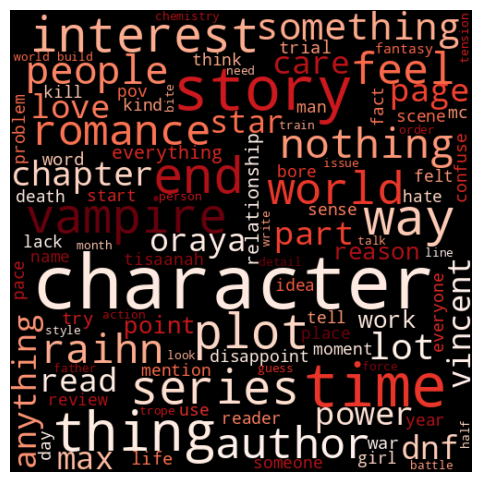

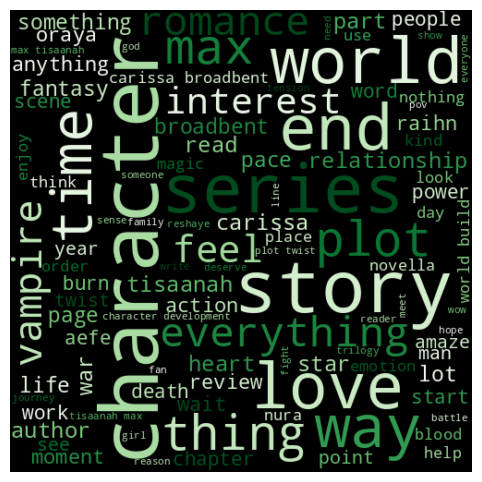

In [ ]:
# Collecting positive and negative aspects
positive_aspect = visualize_df[visualize_df['sentiment_label'] == 1]
negative_aspect = visualize_df[visualize_df['sentiment_label'] == 0]

# Wordcloud for negative nouns
all_negative_aspects = ' '.join(word for word in negative_aspect['nouns_merge'])
wordcloud_negative = WordCloud(colormap='Reds_r', width=500, height=500, mode='RGBA', background_color='black', max_words=100).generate(all_negative_aspects)
plt.figure(figsize=(9, 6))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('')
plt.margins(x=0, y=0)
plt.show()

# Wordcloud for positive nouns
all_positive_aspects = ' '.join(word for word in positive_aspect['nouns_merge'])
wordcloud_positive = WordCloud(colormap='Greens_r', width=500, height=500, mode='RGBA', background_color='black', max_words=100).generate(all_positive_aspects)
plt.figure(figsize=(9, 6))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('')
plt.margins(x=0, y=0)
plt.show()

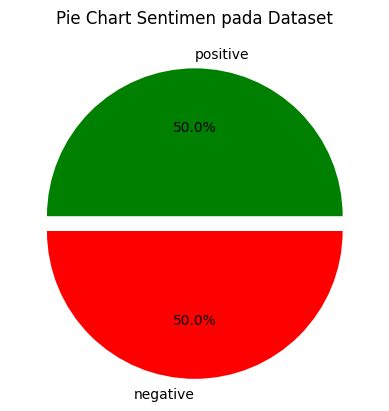

In [ ]:
# Plot a pie chart for sentiment distribution
sentiment_data = visualize_df['sentiment_label']
plt.pie(
    sentiment_data.value_counts(),
    labels=['positive', 'negative'],
    explode=[0, 0.1],
    autopct='%1.1f%%',
    colors=['green', 'red']
)
plt.title('Pie Chart Sentimen pada Dataset')
plt.show()

In [ ]:
# Read the cleaned dataset
dataset_clean = pd.read_csv("./dataset_clean.csv")

# Select relevant columns
dataset_clean = dataset_clean[['clean_text', 'sentiment_label']]

# Replace sentiment labels with numerical values
dataset_clean = dataset_clean.replace({'negative': 0, 'positive': 1})

# Display the first 5 rows of the cleaned dataset
dataset_clean.head()

,clean_text,sentiment_label
0,eh want like really either strange spot come s...,0
1,struggle get book thing help get introduction ...,0
2,book way long bore super depress pointless war...,0
3,look excite thing book suggest watch paint off...,0
4,felt kind place part twist impress annoy overa...,0


In [ ]:
# Splitting data into training and testing sets with a 90:10 ratio
X = dataset_clean['clean_text']  # Feature: cleaned text
y = dataset_clean['sentiment_label']  # Target: sentiment label

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, shuffle=True, random_state=42
)  # 90:10 split

In [ ]:
print("Jumlah Data Training dan Testing (90:10)")
print("Data Training: \t" + str(len(X_train)))
print("Data Testing : \t" + str(len(X_test)))

Jumlah Data Training dan Testing (90:10)
Data Training: 	1297
Data Testing : 	145


In [ ]:
print("Jumlah nilai kosong di Data Training:")
print(X_train.isnull().sum())

print("Jumlah nilai kosong di Data Testing:")
print(X_test.isnull().sum())

Jumlah nilai kosong di Data Training:
1
Jumlah nilai kosong di Data Testing:
0


In [ ]:
# Fill missing values in training and testing data with an empty string
X_train = X_train.fillna("")
X_test = X_test.fillna("")

In [ ]:
# Count Vectorizer for training and testing data
count_vectorizer = CountVectorizer()
X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

# Oversample the training data using SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_count, y_train)

In [ ]:
# Find the maximum number of samples per class after oversampling
value_count = y_train_res.value_counts()
index_range = int(value_count.max() * len(value_count))
index_range

1300

In [ ]:
# Loop to find the best number of neighbors (n_neighbors) based on training data
acc = []
for i in range(1, index_range + 1):  # Start from 1 neighbor
    neigh = KNeighborsClassifier(n_neighbors=i).fit(X_train_res, y_train_res)
    y_pred = neigh.predict(X_test_count)
    accuracy = accuracy_score(y_test, y_pred)
    acc.append(accuracy)

In [ ]:
# Return the n_neighbors value with the highest accuracy
high_acc = acc.index(max(acc)) + 1
high_acc

217

In [ ]:
# Train a K-Nearest Neighbors model with the best n_neighbors value
neigh = KNeighborsClassifier(n_neighbors=high_acc).fit(X_train_res, y_train_res)

# Predict the labels for the test data
y_pred = neigh.predict(X_test_count)

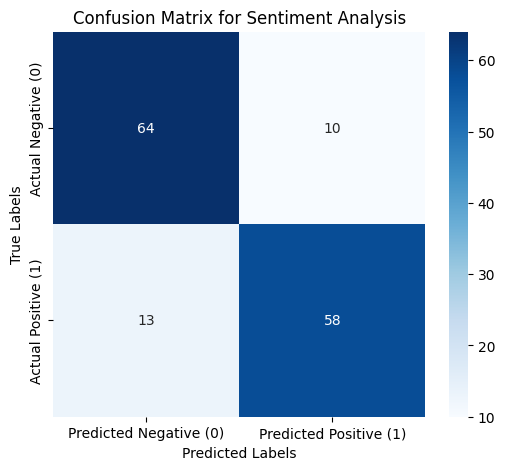

Accuracy: 0.8413793103448276


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Negative (0)", "Predicted Positive (1)"],
    yticklabels=["Actual Negative (0)", "Actual Positive (1)"]
)
plt.title("Confusion Matrix for Sentiment Analysis")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Calculate accuracy
accuracy = (cm[0, 0] + cm[1, 1]) / cm.sum()
print("Accuracy:", accuracy)

In [ ]:
# 1 Define a function to evaluate the model
def evaluate_model(y_pred, y_actual):
    print(classification_report(y_true=y_actual, y_pred=y_pred))
    # Confusion matrix
    cm = confusion_matrix(y_true=y_actual, y_pred=y_pred)
    TN = cm[0, 0]
    FP = cm[0, 1]
    FN = cm[1, 0]
    TP = cm[1, 1]
    # Calculate Sensitivity
    sensitivity = round(TP / float(FN + TP), 2)
    print("Sensitivity: {}".format(sensitivity))
    # Calculate Specificity
    specificity = round(TN / float(TN + FP), 2)
    print("Specificity: {}".format(specificity))
    # Calculate F1 Score
    f1 = f1_score(y_actual, y_pred)
    print("F1 Score: {}".format(round(f1, 2)))

# 2 Prediction on Train Data
y_pred_train = neigh.predict(X_train_res)

# 3 Prediction on Test Data
y_pred_test = neigh.predict(X_test_count)

# 4 Evaluation on Train Data
print("Evaluation on Train dataset ..")
evaluate_model(y_pred=y_pred_train, y_actual=y_train_res)
accuracy = accuracy_score(y_train_res, y_pred_train)
print("K-Nearest Neighbour Model Accuracy (Train): {}".format(round(accuracy, 2)))
print('\n')

# 5 Evaluation on Test Data
print("Evaluation on Test dataset ..")
evaluate_model(y_pred=y_pred_test, y_actual=y_test)
accuracy = accuracy_score(y_test, y_pred_test)
print("K-Nearest Neighbour Model Accuracy (Test): {}".format(round(accuracy, 2)))

Evaluation on Train dataset ..
              precision    recall  f1-score   support

           0       0.75      0.72      0.73       650
           1       0.73      0.76      0.74       650

    accuracy                           0.74      1300
   macro avg       0.74      0.74      0.74      1300
weighted avg       0.74      0.74      0.74      1300

Sensitivity: 0.76
Specificity: 0.72
F1 Score: 0.74
K-Nearest Neighbour Model Accuracy (Train): 0.74


Evaluation on Test dataset ..
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        74
           1       0.85      0.82      0.83        71

    accuracy                           0.84       145
   macro avg       0.84      0.84      0.84       145
weighted avg       0.84      0.84      0.84       145

Sensitivity: 0.82
Specificity: 0.86
F1 Score: 0.83
K-Nearest Neighbour Model Accuracy (Test): 0.84


In [ ]:
# Display the first 5 rows of the dataset
dataset.head()

,authors,book_names,usernames,ratings,reviews,word_count,language,cleaned_reviews,sentiment,sentiment_label
0,Carissa Broadbent,The Songbird & the Heart of Stone,Clace Logan,No Rating,The cover is HEAVENLY 😍Safe to say all the edi...,19,en,cover heavenly say edition book shelf,undecided,0
1,Carissa Broadbent,The Songbird & the Heart of Stone,SK,No Rating,I NEED this!! Am 100% sure this is gonna serve,10,en,need sure gon na serve,undecided,0
2,Carissa Broadbent,The Songbird & the Heart of Stone,♥︎ Heather ⚔,No Rating,Omg November is so far 😩 this cover is everyth...,19,en,omg november far cover everything need iti wan...,undecided,0
3,Carissa Broadbent,The Songbird & the Heart of Stone,blank ⁺‧₊˚ ཐི⋆♱⋆ཋྀ ˚₊‧⁺,No Rating,I GOT THE ARC I GOT THE ARC I GOT THE ARCTHIS ...,19,en,got arc got arc got arcthis drilli got arc,undecided,0
4,Carissa Broadbent,The Songbird & the Heart of Stone,Books_and_Crafts,5,Speechless.If you have been following me for a...,224,en,following amount time know much love broadbent...,positive,1


In [ ]:
# Create a reverse mapping for your label encoder
reverse_label_mapping = {1: 'positive', 0: 'negative'}

# Handle 'No Rating' data
no_rating_dataset = dataset[dataset['ratings'] == 'No Rating']
no_rating_dataset = no_rating_dataset.dropna(subset=['cleaned_reviews'])

# Combine training data and 'No Rating' data
all_reviews = pd.concat([X_train, no_rating_dataset['cleaned_reviews']], ignore_index=True)

# Train a TF-IDF vectorizer on the combined data
word_vectorizer = TfidfVectorizer(max_features=6852 , stop_words='english')
word_vectorizer.fit(all_reviews)

# Transform training data and 'No Rating' data using the same vectorizer
X_train_transformed = word_vectorizer.transform(X_train)
X_no_rating = word_vectorizer.transform(no_rating_dataset['cleaned_reviews'])

# Predict the sentiment for 'No Rating' reviews
no_rating_predictions = neigh.predict(X_no_rating)

# Add the predicted sentiment to the 'No Rating' dataset
no_rating_dataset['sentiment'] = [reverse_label_mapping[pred] for pred in no_rating_predictions]

# Output the results
print("Predicted Sentiment for 'No Rating' Reviews:")
display(no_rating_dataset[['ratings', 'cleaned_reviews', 'sentiment']])

Predicted Sentiment for 'No Rating' Reviews:


,ratings,cleaned_reviews,sentiment
0,No Rating,cover heavenly say edition book shelf,positive
1,No Rating,need sure gon na serve,positive
2,No Rating,omg november far cover everything need iti wan...,positive
3,No Rating,got arc got arc got arcthis drilli got arc,negative
5,No Rating,thought getting septimus mische story love int...,positive
...,...,...,...
18192,No Rating,see hype recently got tattoo galactic snake fe...,positive
18706,No Rating,really enjoyed book delighted find two book av...,negative
18820,No Rating,full review shit glad succumbed hype amazing n...,positive
18829,No Rating,ngl slapped,negative


In [ ]:
# Display the entire 'No Rating' dataset with predicted sentiments
display(no_rating_dataset)

,authors,book_names,usernames,ratings,reviews,word_count,language,cleaned_reviews,sentiment,sentiment_label
0,Carissa Broadbent,The Songbird & the Heart of Stone,Clace Logan,No Rating,The cover is HEAVENLY 😍Safe to say all the edi...,19,en,cover heavenly say edition book shelf,positive,0
1,Carissa Broadbent,The Songbird & the Heart of Stone,SK,No Rating,I NEED this!! Am 100% sure this is gonna serve,10,en,need sure gon na serve,positive,0
2,Carissa Broadbent,The Songbird & the Heart of Stone,♥︎ Heather ⚔,No Rating,Omg November is so far 😩 this cover is everyth...,19,en,omg november far cover everything need iti wan...,positive,0
3,Carissa Broadbent,The Songbird & the Heart of Stone,blank ⁺‧₊˚ ཐི⋆♱⋆ཋྀ ˚₊‧⁺,No Rating,I GOT THE ARC I GOT THE ARC I GOT THE ARCTHIS ...,19,en,got arc got arc got arcthis drilli got arc,negative,0
5,Carissa Broadbent,The Songbird & the Heart of Stone,Ri ♡,No Rating,And here i thought we were getting septimus an...,35,en,thought getting septimus mische story love int...,positive,0
...,...,...,...,...,...,...,...,...,...,...
18192,Carissa Broadbent,The Serpent and the Wings of Night,Ashley Muzz,No Rating,About to see what the hype is about! I recentl...,27,en,see hype recently got tattoo galactic snake fe...,positive,0
18706,Carissa Broadbent,The Serpent and the Wings of Night,Nancy,No Rating,Really enjoyed this book. I was VERY delighted...,80,en,really enjoyed book delighted find two book av...,negative,0
18820,Carissa Broadbent,The Serpent and the Wings of Night,Tanisha Smith,No Rating,Full review to come.Holy Shit …. So glad I suc...,22,en,full review shit glad succumbed hype amazing n...,positive,0
18829,Carissa Broadbent,The Serpent and the Wings of Night,readingwithki,No Rating,ngl this slapped,3,en,ngl slapped,negative,0


In [ ]:
# Combine rated dataset and 'No Rating' dataset
dataset_to_predict = pd.concat([rated_dataset, no_rating_dataset])

# Drop rows with missing sentiment values
dataset_to_predict = dataset_to_predict.dropna(subset=['sentiment'])

# Remove duplicate rows based on 'cleaned_reviews'
dataset_to_predict = dataset_to_predict.drop_duplicates(subset=['cleaned_reviews'])

# Reset the index for a cleaner DataFrame
dataset_to_predict.reset_index(drop=True, inplace=True)

# Drop rows where 'book_names' is "No tittle"
dataset_to_predict = dataset_to_predict[dataset_to_predict['book_names'] != "No tittle"]

# Save the final dataset to an Excel file
dataset_to_predict.to_excel('dataset_to_predict.xlsx', index=False)

# Display the final dataset
display(dataset_to_predict)

,authors,book_names,usernames,ratings,reviews,word_count,language,cleaned_reviews,sentiment,sentiment_label
0,Carissa Broadbent,The Songbird & the Heart of Stone,Books_and_Crafts,5,Speechless.If you have been following me for a...,224,en,following amount time know much love broadbent...,positive,1
1,Carissa Broadbent,The Songbird & the Heart of Stone,Sara Machado (partially inactive - on vacation),5,This book! The story! The ending! The epilogue...,230,en,book story ending epilogue carissa need book i...,positive,1
2,Carissa Broadbent,The Songbird & the Heart of Stone,carolina ୨♡୧ ִ° ⋆,5,This is the tale of how a chosen one falls. Sh...,1272,en,tale chosen one fall screaming clawing old lif...,positive,1
3,Carissa Broadbent,The Songbird & the Heart of Stone,Rachel Rowell,5,I AM THE CHOSEN ONE 🌞🌞🌞🌞🌞 ALL MY LOVE to Caris...,25,en,chosen one love carissa caro tor privilege rec...,positive,1
4,Carissa Broadbent,The Songbird & the Heart of Stone,Booksblabbering || Cait❣️,4,"A girl who can only love broken things, and a ...",362,en,girl love broken thing boy broken love left or...,positive,1
...,...,...,...,...,...,...,...,...,...,...
14489,Carissa Broadbent,The Serpent and the Wings of Night,Ashley Muzz,No Rating,About to see what the hype is about! I recentl...,27,en,see hype recently got tattoo galactic snake fe...,positive,0
14490,Carissa Broadbent,The Serpent and the Wings of Night,Nancy,No Rating,Really enjoyed this book. I was VERY delighted...,80,en,really enjoyed book delighted find two book av...,negative,0
14491,Carissa Broadbent,The Serpent and the Wings of Night,Tanisha Smith,No Rating,Full review to come.Holy Shit …. So glad I suc...,22,en,full review shit glad succumbed hype amazing n...,positive,0
14492,Carissa Broadbent,The Serpent and the Wings of Night,readingwithki,No Rating,ngl this slapped,3,en,ngl slapped,negative,0


In [ ]:
# Assign the trained word vectorizer and model
word_vectorizer = word_vectorizer
model = neigh

# Create the directory if it doesn't exist
os.makedirs('./model', exist_ok=True)

# Save the KNN model
pickle.dump(model, open('./model/knn_model.pkl', 'wb'))

# Save the Word Vectorizer
pickle.dump(word_vectorizer, open('./model/word_vectorizer.pkl', 'wb'))


# Recommendation

In [ ]:
# Define a function to create pivot tables
def apply_pivot(df, fillby=None):
    if fillby is not None:
        return df.pivot_table(index='usernames', columns='book_names', values='ratings').fillna(fillby)
    return df.pivot_table(index='usernames', columns='book_names', values='ratings')

# 1 Divide the dataset into train and test sets
train, test = train_test_split(dataset_to_predict, test_size=0.1, random_state=42)

# Ensure test users are present in train set
test = test[test.usernames.isin(train.usernames)]

# Replace 'No Rating' with 0 in the 'ratings' column
train['ratings'] = pd.to_numeric(train['ratings'], errors='coerce').fillna(0)
test['ratings'] = pd.to_numeric(test['ratings'], errors='coerce').fillna(0)

# 2 Apply pivot operation and fill missing values with 0
df_train_pivot = apply_pivot(df=train, fillby=0)
df_test_pivot = apply_pivot(df=test, fillby=0)

# 3 Create dummy datasets for train and test
## Train
dummy_train = train.copy()
dummy_train['ratings'] = dummy_train['ratings'].apply(lambda x: 0 if x >= 1 else 1)
dummy_train = apply_pivot(df=dummy_train, fillby=1)

## Test
dummy_test = test.copy()
dummy_test['ratings'] = dummy_test['ratings'].apply(lambda x: 1 if x >= 1 else 0)
dummy_test = apply_pivot(df=dummy_test, fillby=0)

In [ ]:
# Filter rows in the training pivot table where either
# 'The Serpent and the Wings of Night' or 'The Songbird & the Heart of Stone' has a non-zero value
df_train_pivot[(df_train_pivot['The Serpent and the Wings of Night'] != 0) |
               (df_train_pivot['The Songbird & the Heart of Stone'] != 0)]

book_names,A Palace Fractured,Ashen Son,Children of Fallen Gods,Daughter of No Worlds,Fierce Hearts,Flirting with Darkness,Mother of Death & Dawn,Realm of Darkness,Six Scorched Roses,Slaying the Vampire Conqueror,The Ashes & the Star-Cursed King,The Serpent and the Wings of Night,The Songbird & the Heart of Stone
usernames,,,,,,,,,,,,,
&#x1d4e2;,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
&#x1f338; Tana &#x1f338;,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,5.0,0.0
&#x1f48c; crystal,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
&#x1f90d;Coral Jade&#x1f90d;,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
* ੈ‧ ✧ ₊˚☆ julie ʚїɞ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
❀ Kelly ❀,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,5.0,0.0,5.0,0.0
❀ Rose ❀,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0
❀ mariana ❀,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,5.0,0.0


In [ ]:
# Calculate the mean ratings using only the ratings given by the user (do not include 0)
mean = np.nanmean(apply_pivot(df=train), axis=1)

# Subtract the mean rating for each user from their ratings
df_train_subtracted = (apply_pivot(df=train).T - mean).T

# Replace NaN values with 0 for users who haven't given a rating
df_train_subtracted.fillna(0, inplace=True)

# Compute the User Similarity Matrix using cosine similarity
user_correlation = 1 - pairwise_distances(df_train_subtracted, metric='cosine')

# Replace NaN values in the similarity matrix with 0
user_correlation[np.isnan(user_correlation)] = 0

# Convert the similarity matrix to a DataFrame
user_correlation_df = pd.DataFrame(user_correlation)

# Add usernames as the index and column labels
user_correlation_df['usernames'] = df_train_subtracted.index
user_correlation_df.set_index('usernames', inplace=True)
user_correlation_df.columns = df_train_subtracted.index.tolist()

In [ ]:
# Display the shapes of the user correlation matrix and the training pivot table
user_correlation.shape, df_train_pivot.shape

((7790, 7790), (7790, 13))

In [ ]:
# Calculate predicted ratings as the weighted sum of correlations and product ratings
user_predicted_ratings = np.dot(user_correlation, df_train_pivot)

# Ignore the products already rated by users by multiplying with dummy_train
user_final_rating = np.multiply(user_predicted_ratings, dummy_train)

# Optional: Scale the final ratings to a specified range (e.g., 1 to 5)
# scaler = MinMaxScaler(feature_range=(1, 5))
# scaler.fit(user_final_rating)
# user_final_rating = scaler.transform(user_final_rating)

In [ ]:
# Count the occurrences of each username in the dataset
target = dataset_to_predict.usernames.value_counts()

# Display the result
target

,count
usernames,
Sarah,66
Emily,53
Jessica,50
Rachel,44
Ashley,40
...,...
juldireads,1
Giuliana Lucca,1
jess_is_book_obsessed,1


In [ ]:
# Select the second most frequent username as the target for prediction
target_predict = target.index[1]

In [ ]:
# Function to find top N recommendations for a specific user
def find_top_recommendations(pred_rating_df, usernames, topn):
    # Extract the predicted ratings for the user and sort them in descending order
    recommendation = pred_rating_df.loc[usernames].sort_values(ascending=False)[0:topn]

    # Convert the recommendations into a DataFrame with 'predicted_ratings' column
    recommendation = pd.DataFrame(recommendation).reset_index().rename(columns={usernames: 'predicted_ratings'})

    return recommendation

# Set the target user for recommendation (from the earlier calculation)
user_input = target_predict

# Get top 5 recommendations for the target user
recommendation_user_user = find_top_recommendations(user_final_rating, user_input, 6)

# Add a column with the username for context
recommendation_user_user['usernames'] = user_input

# Display recommended products for the user
print("Recommended products for usernames: {} as below".format(user_input))
display(recommendation_user_user)

# Display earlier rated products by the user
print("Earlier rated products by usernames: {} as below".format(user_input))
display(train[train['usernames'] == user_input].sort_values(['ratings'], ascending=False))

Recommended products for usernames: Emily as below


,book_names,predicted_ratings,usernames
0,Daughter of No Worlds,25.174724,Emily
1,The Songbird & the Heart of Stone,8.494451,Emily
2,Realm of Darkness,7.061118,Emily
3,Flirting with Darkness,4.933222,Emily
4,Ashen Son,1.564042,Emily
5,Fierce Hearts,0.635158,Emily


Earlier rated products by usernames: Emily as below


,authors,book_names,usernames,ratings,reviews,word_count,language,cleaned_reviews,sentiment,sentiment_label
13293,Carissa Broadbent,The Serpent and the Wings of Night,Emily,5.0,I’d like to die and come back to life to read ...,17,en,like die come back life read first time,positive,1
12349,Carissa Broadbent,The Serpent and the Wings of Night,Emily,5.0,Wow this was a great rollercoaster. I legit ne...,282,en,wow great rollercoaster legit never knew going...,positive,1
10380,Carissa Broadbent,The Serpent and the Wings of Night,Emily,5.0,I am addicted to this there is no other way ar...,12,en,addicted way around,positive,1
1762,Carissa Broadbent,Six Scorched Roses,Emily,5.0,this book made my heart genuinely ache & grow ...,41,en,book made heart genuinely ache grow like size ...,positive,1
560,Carissa Broadbent,Children of Fallen Gods,Emily,5.0,4.75⭐️Usually I don’t ✨share✨ my reviews becau...,187,en,review lazy afraid opinion invalid however ser...,positive,1
11701,Carissa Broadbent,The Serpent and the Wings of Night,Emily,5.0,I honestly really loved this book. It kind of ...,68,en,honestly really loved book kind took second ge...,positive,1
9122,Carissa Broadbent,Daughter of No Worlds,Emily,5.0,4.5 stars! Tisaanah was captured as a slave wh...,176,en,star tisaanah captured slave year old year old...,positive,1
3321,Carissa Broadbent,The Ashes & the Star-Cursed King,Emily,5.0,ok so do not get me wrong when I say that the ...,135,en,ok get wrong say daughter world trilogy consum...,positive,1
2761,Carissa Broadbent,The Ashes & the Star-Cursed King,Emily,5.0,8/8/24: five stars on the re-readOriginal: 4.5...,10,en,five star star rounded,positive,1
3792,Carissa Broadbent,Mother of Death & Dawn,Emily,5.0,There was no reason for me to upend my entire ...,64,en,reason upend entire tbr final week binge serie...,positive,1


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Fungsi untuk menghitung RMSE
def calculate_rmse(true_ratings, predicted_ratings):
    """Menghitung RMSE antara true ratings dan predicted ratings."""
    true_ratings = np.nan_to_num(true_ratings, nan=0)  # Menangani NaN
    predicted_ratings = np.nan_to_num(predicted_ratings, nan=0)  # Menangani NaN
    return np.sqrt(np.nanmean((true_ratings - predicted_ratings) ** 2))  # Rata-rata kuadrat perbedaan

# Fungsi untuk menghitung MAE
def calculate_mae(true_ratings, predicted_ratings):
    """Menghitung MAE antara true ratings dan predicted ratings."""
    true_ratings = np.nan_to_num(true_ratings, nan=0)  # Menangani NaN
    predicted_ratings = np.nan_to_num(predicted_ratings, nan=0)  # Menangani NaN
    return np.nanmean(np.abs(true_ratings - predicted_ratings))  # Rata-rata perbedaan absolut

# Prediksi pengguna setelah perkalian matriks
user_correlation_test_df = user_correlation_df[user_correlation_df.index.isin(test.usernames)]
user_correlation_test_df = user_correlation_test_df[list(set(test.usernames))]

# Matriks prediksi rating pengguna berdasarkan perkalian dengan pivot table
test_user_predicted_ratings = np.dot(user_correlation_test_df, df_test_pivot)

# Mengabaikan produk yang sudah dinilai dengan mengalikan dengan dummy_test
test_user_predicted_ratings = np.multiply(test_user_predicted_ratings, dummy_test)

# Set NaN untuk entri yang tidak diberi rating oleh pengguna
test_user_predicted_ratings[test_user_predicted_ratings <= 0] = np.nan  # Menjaga rating hanya untuk produk yang dinilai

# Normalisasi rating prediksi ke rentang [1, 5]
scaler = MinMaxScaler(feature_range=(1, 5))

# Pastikan normalisasi dilakukan hanya jika nilai rating valid ada
test_user_predicted_ratings_np = np.array(test_user_predicted_ratings)  # Konversi ke array numpy jika menggunakan pandas DataFrame

# Periksa apakah ada nilai NaN dalam array numpy
if np.isnan(test_user_predicted_ratings_np).any():
    # Ganti NaN dengan nilai default (misalnya 0) sebelum normalisasi
    test_user_predicted_ratings_np = np.nan_to_num(test_user_predicted_ratings_np, nan=0)

    # Lakukan normalisasi
    scaler.fit(test_user_predicted_ratings_np)
    test_user_predicted_ratings = scaler.transform(test_user_predicted_ratings_np)
else:
    print("Warning: All values in test_user_predicted_ratings are NaN. Skipping scaling.")

# Pastikan bentuk data konsisten sebelum menghitung RMSE dan MAE
if test_user_predicted_ratings.shape != apply_pivot(df=test).shape:
    print("Error: Shape mismatch between test_user_predicted_ratings and test pivot table.")
else:
    # Hitung RMSE hanya jika bentuk data sesuai
    total_non_nan = np.count_nonzero(~np.isnan(test_user_predicted_ratings))
    if total_non_nan > 0:
        rmse = calculate_rmse(apply_pivot(df=test).values, test_user_predicted_ratings)
        print(f"RMSE: {rmse:.4f}")
    else:
        print("No valid ratings to calculate RMSE.")

# Hitung MAE
if test_user_predicted_ratings.shape != apply_pivot(df=test).shape:
    print("Error: Shape mismatch between test_user_predicted_ratings and test pivot table.")
else:
    # Flatten the difference matrix to a single array and calculate MAE
    absolute_error = np.abs(apply_pivot(df=test).values - test_user_predicted_ratings)
    mae = calculate_mae(apply_pivot(df=test).values, test_user_predicted_ratings)
    print(f"MAE: {mae:.4f}")

RMSE: 1.3704
MAE: 1.1894


In [ ]:
# Check if there are NaN values in test_user_predicted_ratings and replace with 0 if all values are NaN
if not np.isnan(test_user_predicted_ratings).all():
    # Replace NaN with a default value (e.g., 0)
    test_user_predicted_ratings = np.nan_to_num(test_user_predicted_ratings, nan=0)

    # Scale the ratings to the range [1, 5]
    scaler = MinMaxScaler(feature_range=(1, 5))
    test_user_predicted_ratings = scaler.fit_transform(test_user_predicted_ratings)
else:
    print("Warning: All values in test_user_predicted_ratings are NaN. Skipping scaling.")
    # Replace NaN values with 0 and reshape it to match the pivot table shape if necessary
    test_user_predicted_ratings = np.zeros_like(apply_pivot(df=test).values)

# Ensure the final ratings have been properly scaled or replaced
print(test_user_predicted_ratings)

[[1.         1.         1.         ... 1.         1.         1.        ]
 [1.         1.         1.         ... 3.20059375 1.         1.        ]
 [1.         1.         1.         ... 1.         1.         1.        ]
 ...
 [1.         1.         1.         ... 1.         1.         1.        ]
 [1.         1.         1.         ... 1.         1.         1.        ]
 [1.         1.         1.         ... 1.         1.         1.        ]]


In [ ]:
# Save the final user ratings model to a pickle file
pickle.dump(user_final_rating, open('./model/user_final_rating.pkl', 'wb'))

# Connecting dot -- Use Sentiment in Improving Recommendation

In [ ]:
top_n = 6

In [ ]:
# Function to get top N recommendations based on predicted ratings
def find_top_recommendations(pred_rating_df, usernames, topn):
    # Sort the predicted ratings for the given user and select top N recommendations
    recommendation = pred_rating_df.loc[usernames].sort_values(ascending=False)[0:topn]
    # Convert to DataFrame and rename columns for readability
    recommendation = pd.DataFrame(recommendation).reset_index().rename(columns={usernames: 'predicted_ratings'})
    # Scaling predicted ratings to the range 0-5
    scaler = MinMaxScaler(feature_range=(1, 5))
    recommendation['predicted_ratings'] = scaler.fit_transform(recommendation[['predicted_ratings']])[:, 0]
    return recommendation

# Function to get the sentiment score for a given product based on its reviews
def get_sentiment_product(x):
    # Get the reviews for the specified product
    product_name_review_list = dataset_to_predict[dataset_to_predict['book_names'] == x]['reviews'].tolist()
    # Transform reviews into Document Term Matrix (DTM)
    features = word_vectorizer.transform(product_name_review_list)
    # Predict the sentiment of the product (average sentiment across all reviews)
    return model.predict(features).mean()

# Function to find the top N positive recommendations for a given user based on user-user similarity
def find_top_pos_recommendation(user_final_rating, user_input, df_prod_review, word_vectorizer, model, no_recommendation):
    # Generate top recommendations using user-user based recommendation system without sentiment analysis
    recommendation_user_user = find_top_recommendations(user_final_rating, user_input, top_n)
    recommendation_user_user['usernames'] = user_input

    # Filter out recommendations where predicted rating is zero (no interest)
    recommendation_user_user = recommendation_user_user[recommendation_user_user['predicted_ratings'] != 0]
    print("Recommended products for usernames:{} without using sentiment".format(user_input))
    display(recommendation_user_user)

    # Get overall sentiment score for each recommended product
    recommendation_user_user['sentiment_score'] = recommendation_user_user['book_names'].apply(get_sentiment_product)

    # Normalize the sentiment score to match the scale of predicted ratings (1–5)
    scaler = MinMaxScaler(feature_range=(1, 5))
    scaler.fit(recommendation_user_user[['sentiment_score']])
    recommendation_user_user['sentiment_score'] = scaler.transform(recommendation_user_user[['sentiment_score']])

    # Calculate final product ranking score (1*Predicted rating + 2*Normalized sentiment score)
    recommendation_user_user['product_ranking_score'] = 1 * recommendation_user_user['predicted_ratings'] + \
                                                        2 * recommendation_user_user['sentiment_score']
    print("Recommended products for usernames:{} after using sentiment".format(user_input))

    # Sort product ranking scores in descending order and show the top 'no_recommendation' products
    display(recommendation_user_user.sort_values(by=['product_ranking_score'], ascending=False).head(no_recommendation))

In [ ]:
# Set the target user for recommendation (from the earlier calculation)
user_input = target_predict

# Call the function to get the top 7 recommendations for the user
find_top_pos_recommendation(user_final_rating, user_input, dataset_to_predict, word_vectorizer, model, no_recommendation=top_n)

Recommended products for usernames:Emily without using sentiment


,book_names,predicted_ratings,usernames
0,Daughter of No Worlds,5.000000,Emily
1,The Songbird & the Heart of Stone,2.281081,Emily
2,Realm of Darkness,2.047445,Emily
3,Flirting with Darkness,1.700593,Emily
4,Ashen Son,1.151410,Emily
5,Fierce Hearts,1.000000,Emily


Recommended products for usernames:Emily after using sentiment


,book_names,predicted_ratings,usernames,sentiment_score,product_ranking_score
1,The Songbird & the Heart of Stone,2.281081,Emily,5.000000,12.281081
0,Daughter of No Worlds,5.000000,Emily,1.902395,8.804790
5,Fierce Hearts,1.000000,Emily,3.012903,7.025806
2,Realm of Darkness,2.047445,Emily,2.397849,6.843144
3,Flirting with Darkness,1.700593,Emily,1.000000,3.700593
4,Ashen Son,1.151410,Emily,1.127630,3.406669


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

# --- Fungsi untuk menghitung RMSE dan MAE ---

def calculate_rmse(true_ratings, predicted_ratings):
    """Menghitung RMSE antara true ratings dan predicted ratings."""
    # Menangani nilai NaN (diganti dengan 0 untuk perhitungan RMSE)
    true_ratings = np.nan_to_num(true_ratings, nan=0)
    predicted_ratings = np.nan_to_num(predicted_ratings, nan=0)
    # Menghitung RMSE
    rmse = np.sqrt(np.mean((true_ratings - predicted_ratings)**2))
    return rmse

def calculate_mae(true_ratings, predicted_ratings):
    """Menghitung MAE antara true ratings dan predicted ratings."""
    # Menangani nilai NaN (diganti dengan 0 untuk perhitungan MAE)
    true_ratings = np.nan_to_num(true_ratings, nan=0)
    predicted_ratings = np.nan_to_num(predicted_ratings, nan=0)
    # Menghitung MAE
    mae = np.mean(np.abs(true_ratings - predicted_ratings))
    return mae

# --- RMSE & MAE tanpa sentimen ---

print(f"RMSE tanpa sentimen: {rmse:.4f}")
print(f"MAE tanpa sentimen: {mae:.4f}")


# --- RMSE & MAE dengan sentimen ---

# predicted_ratings_with_sentiment adalah matriks predicted ratings dari sistem rekomendasi dengan sentimen
# Filter user_final_rating to include only users and items present in the test set
# Convert user_final_rating to DataFrame for easier indexing
user_final_rating_df = pd.DataFrame(user_final_rating, index=df_train_pivot.index, columns=df_train_pivot.columns)
predicted_ratings_with_sentiment = user_final_rating_df.loc[
    df_test_pivot.index, df_test_pivot.columns
].values

# Reshape true_ratings to match the shape of predicted_ratings_with_sentiment
true_ratings_reshaped = apply_pivot(df=test).values  # Get the true ratings in the same shape

# Normalisasi predicted_ratings_with_sentiment ke rentang [1, 5] jika diperlukan
scaler = MinMaxScaler(feature_range=(0, 1))  # Adjust the range if needed
predicted_ratings_with_sentiment = scaler.fit_transform(predicted_ratings_with_sentiment)

# Calculate RMSE and MAE with sentiment
rmse_with_sentiment = calculate_rmse(true_ratings_reshaped, predicted_ratings_with_sentiment)
mae_with_sentiment = calculate_mae(true_ratings_reshaped, predicted_ratings_with_sentiment)

print(f"RMSE dengan sentimen: {rmse_with_sentiment:.4f}")
print(f"MAE dengan sentimen: {mae_with_sentiment:.4f}")

RMSE tanpa sentimen: 1.3704
MAE tanpa sentimen: 1.1894
RMSE dengan sentimen: 1.3288
MAE dengan sentimen: 0.8381
